# Documento para aprender a biblioteca Pandas e Numpy

In [1]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [2]:
df_scada = pd.read_csv("Datasets/SCADA/EDP-SCADA-2017.csv")

df_scada

,Turbine_ID,Timestamp,Gen_RPM_Max,Gen_RPM_Min,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Phase1_Temp_Avg,Gen_Phase2_Temp_Avg,Gen_Phase3_Temp_Avg,...,Grd_Prod_PsbleInd_Avg,Grd_Prod_PsbleInd_Max,Grd_Prod_PsbleInd_Min,Grd_Prod_PsbleInd_Std,Grd_Prod_PsbleCap_Avg,Grd_Prod_PsbleCap_Max,Grd_Prod_PsbleCap_Min,Grd_Prod_PsbleCap_Std,Gen_Bear2_Temp_Avg,Nac_Direction_Avg
0,T06,2017-12-29T20:30:00+00:00,1344.0,265.3,647.1,476.4,43.0,56,57,57,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39,277.4
1,T01,2017-12-29T20:30:00+00:00,289.9,238.5,265.5,13.1,40.0,54,54,54,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,35,285.9
2,T06,2017-12-29T20:40:00+00:00,311.0,275.0,293.1,8.9,43.0,53,54,53,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,38,281.2
3,T07,2017-12-29T20:40:00+00:00,1255.5,1239.3,1248.8,2.9,39.0,63,63,63,...,-143.2,-5.7,-310.4,55.3,143.2,310.4,5.7,55.3,36,290.9
4,T01,2017-12-29T20:40:00+00:00,316.0,269.4,291.4,11.5,39.0,51,51,51,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,34,301.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209231,T01,2017-05-31T10:50:00+00:00,1700.7,1362.5,1619.8,68.0,55.0,89,87,86,...,-998.4,-654.3,-1000.0,17.3,953.4,1000.0,443.4,95.5,65,123.8
209232,T06,2017-06-03T00:20:00+00:00,0.0,0.0,0.0,0.0,42.0,45,46,46,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36,90.3
209233,T11,2017-05-31T11:10:00+00:00,1675.5,1299.7,1565.7,102.2,64.0,72,73,73,...,-1000.0,-1000.0,-1000.0,0.0,1000.0,1000.0,1000.0,0.0,53,106.6
209234,T06,2017-06-03T00:50:00+00:00,0.0,0.0,0.0,0.0,39.0,41,41,41,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,34,90.3


In [3]:
# Verificar se o Timestamp esta no formato correto
df_scada['Timestamp'] = pd.to_datetime(df_scada['Timestamp'])

# Filtrar uma das turbinas
df_scada = df_scada[df_scada['Turbine_ID'] == 'T01']

# Organizar em ordem cronologica
df_scada = df_scada.sort_values("Timestamp")
df_scada

,Turbine_ID,Timestamp,Gen_RPM_Max,Gen_RPM_Min,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Phase1_Temp_Avg,Gen_Phase2_Temp_Avg,Gen_Phase3_Temp_Avg,...,Grd_Prod_PsbleInd_Avg,Grd_Prod_PsbleInd_Max,Grd_Prod_PsbleInd_Min,Grd_Prod_PsbleInd_Std,Grd_Prod_PsbleCap_Avg,Grd_Prod_PsbleCap_Max,Grd_Prod_PsbleCap_Min,Grd_Prod_PsbleCap_Std,Gen_Bear2_Temp_Avg,Nac_Direction_Avg
69161,T01,2017-01-01 00:00:00+00:00,1460.9,1239.2,1313.7,47.9,36.0,57,57,57,...,-978.4,-621.9,-1000.0,67.1,978.4,1000.0,621.9,67.1,45,108.1
27022,T01,2017-01-01 00:10:00+00:00,1410.6,1229.4,1271.3,27.6,36.0,57,57,57,...,-900.7,-477.2,-1000.0,120.9,900.7,1000.0,477.2,120.9,44,108.1
27024,T01,2017-01-01 00:20:00+00:00,1444.1,1226.7,1270.4,30.8,36.0,56,56,56,...,-865.2,-291.4,-1000.0,149.3,865.2,1000.0,291.4,149.3,44,114.7
124413,T01,2017-01-01 00:30:00+00:00,1300.0,1228.1,1256.1,11.8,36.0,56,56,56,...,-734.6,-222.0,-1000.0,187.8,734.6,1000.0,222.0,187.8,43,114.7
113493,T01,2017-01-01 00:40:00+00:00,1294.1,1221.2,1252.9,11.2,36.0,56,56,56,...,-496.5,-54.4,-876.1,174.1,496.5,876.1,54.4,174.1,43,114.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,T01,2017-12-31 23:10:00+00:00,1491.3,1260.4,1394.3,64.3,39.0,61,61,60,...,-1000.0,-1000.0,-1000.0,0.0,1000.0,1000.0,1000.0,0.0,38,326.6
243,T01,2017-12-31 23:20:00+00:00,1487.2,1243.7,1403.6,75.6,39.0,61,61,60,...,-1000.0,-1000.0,-1000.0,0.0,1000.0,1000.0,1000.0,0.0,39,331.9
88286,T01,2017-12-31 23:30:00+00:00,1260.2,1240.3,1250.1,3.4,39.0,60,60,60,...,-958.5,-739.8,-1000.0,61.9,958.5,1000.0,739.8,61.9,39,333.6
244,T01,2017-12-31 23:40:00+00:00,1259.5,1239.8,1249.9,3.2,39.0,60,59,59,...,-997.1,-880.4,-1000.0,13.6,997.1,1000.0,880.4,13.6,39,338.7


In [4]:
df_scada.columns

Index(['Turbine_ID', 'Timestamp', 'Gen_RPM_Max', 'Gen_RPM_Min', 'Gen_RPM_Avg',
       'Gen_RPM_Std', 'Gen_Bear_Temp_Avg', 'Gen_Phase1_Temp_Avg',
       'Gen_Phase2_Temp_Avg', 'Gen_Phase3_Temp_Avg', 'Hyd_Oil_Temp_Avg',
       'Gear_Oil_Temp_Avg', 'Gear_Bear_Temp_Avg', 'Nac_Temp_Avg',
       'Rtr_RPM_Max', 'Rtr_RPM_Min', 'Rtr_RPM_Avg', 'Amb_WindSpeed_Max',
       'Amb_WindSpeed_Min', 'Amb_WindSpeed_Avg', 'Amb_WindSpeed_Std',
       'Amb_WindDir_Relative_Avg', 'Amb_WindDir_Abs_Avg', 'Amb_Temp_Avg',
       'Prod_LatestAvg_ActPwrGen0', 'Prod_LatestAvg_ActPwrGen1',
       'Prod_LatestAvg_ActPwrGen2', 'Prod_LatestAvg_TotActPwr',
       'Prod_LatestAvg_ReactPwrGen0', 'Prod_LatestAvg_ReactPwrGen1',
       'Prod_LatestAvg_ReactPwrGen2', 'Prod_LatestAvg_TotReactPwr',
       'HVTrafo_Phase1_Temp_Avg', 'HVTrafo_Phase2_Temp_Avg',
       'HVTrafo_Phase3_Temp_Avg', 'Grd_InverterPhase1_Temp_Avg',
       'Cont_Top_Temp_Avg', 'Cont_Hub_Temp_Avg', 'Cont_VCP_Temp_Avg',
       'Gen_SlipRing_Temp_Avg', 'Spin

# Modelo CNN Teste

### Criar series temporais de tamanho 50 para algumas features || Janelas deslizantes

In [5]:

# temperaturas = [[1..60], [61..120], [121..180] ...]

# X -> X: (batch, channels, seq_len)

features_escolhidas = [
  "Gen_Bear_Temp_Avg",
  "Gen_RPM_Std"
]

# Normalizar
df_scada[features_escolhidas] = (df_scada[features_escolhidas] - df_scada[features_escolhidas].mean()) / df_scada[features_escolhidas].std()

tensor_features = []

for feature in features_escolhidas:

  df_feature = df_scada[feature].values

  tamanho_janela = 50
  
  qtd_valores = len(df_feature)

  series_janelas = []

  for i in range(qtd_valores - tamanho_janela + 1):
    janela = df_feature[i:i + tamanho_janela]
    series_janelas.append(janela)

  tensor_feature = torch.tensor(series_janelas, dtype=torch.float32)

  tensor_features.append(tensor_feature)
  
  print(tensor_feature.shape)
  
X = torch.stack(tensor_features, dim=1)

X.shape

C:\Users\tibis\AppData\Local\Temp\ipykernel_34360\2214311330.py:29: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_new.cpp:281.)
  tensor_feature = torch.tensor(series_janelas, dtype=torch.float32)


torch.Size([52195, 50])
torch.Size([52195, 50])


torch.Size([52195, 2, 50])

### Tentar prever a geracao de energia usando temperatura e rotacao

In [6]:
# Y -> Y: (batch, seq_len)

# Normalizar
df_scada["Grd_Prod_Pwr_Avg"] = (df_scada["Grd_Prod_Pwr_Avg"] - df_scada["Grd_Prod_Pwr_Avg"].mean()) / df_scada["Grd_Prod_Pwr_Avg"].std()

serie_energia = df_scada["Grd_Prod_Pwr_Avg"].values

qtd_valores = len(serie_energia)

tensor_label = []

# Para prever a próxima janela, desloca +1, mas nunca deixa o índice 0 vazio.
for i in range(qtd_valores - tamanho_janela):
    janela = serie_energia[i+1:i+1 + tamanho_janela]
    tensor_label.append(janela)

# Adiciona a última janela normal para manter o mesmo tamanho de X e Y
janela_final = serie_energia[qtd_valores-tamanho_janela:qtd_valores]
tensor_label.append(janela_final)

Y = torch.tensor(tensor_label, dtype=torch.float32)

Y.shape

torch.Size([52195, 50])

### Remover NaNs - nao deixa o modelo treinar

In [7]:
X = torch.nan_to_num(X)
Y = torch.nan_to_num(Y)

In [8]:
print("Primeira série de todas as features (X):")
print(X[0])  # shape: (channels, seq_len)

print("Primeira série de todas as features (Y):")
print(Y[0])  # shape: (channels, seq_len)

Primeira série de todas as features (X):
tensor([[-0.6157, -0.6157, -0.6157, -0.6157, -0.6157, -0.6800, -0.6800, -0.6800,
         -0.6800, -0.6800, -0.6800, -0.6800, -0.6800, -0.6800, -0.6157, -0.6157,
         -0.5513, -0.4869, -0.4869, -0.4225, -0.4225, -0.3582, -0.3582, -0.3582,
         -0.3582, -0.3582, -0.3582, -0.3582, -0.3582, -0.4225, -0.4225, -0.4869,
         -0.4869, -0.4869, -0.4869, -0.5513, -0.5513, -0.5513, -0.6157, -0.6157,
         -0.6157, -0.6800, -0.6800, -0.6800, -0.6800, -0.6800, -0.6800, -0.6800,
         -0.6800, -0.6800],
        [-0.1819, -0.3673, -0.3381, -0.5116, -0.5171, -0.5591, -0.4476, -0.5390,
         -0.3718, -0.3499, -0.3746, -0.2412, -0.1444,  0.0117, -0.3170, -0.0522,
         -0.3435, -0.2869, -0.3563, -0.3910, -0.3344, -0.3636, -0.4860, -0.4741,
         -0.3161, -0.2750,  0.1734,  0.5277, -0.1326, -0.1298,  0.0620,  0.0793,
         -0.0312,  0.0181,  0.2839, -0.1883, -0.2349, -0.3782, -0.3855, -0.4047,
         -0.5097, -0.3362, -0.1928, -0.2

### Modelo CNN com 3 camadas

In [9]:
class CNN1D(nn.Module):
    def __init__(self, in_channels=1, hidden=32, kernel=3):
        super().__init__()
        pad = kernel // 2
        
        self.net = nn.Sequential(
          nn.Conv1d(in_channels=in_channels, out_channels=hidden, kernel_size=kernel, padding=pad),
          nn.ReLU(),
          nn.Conv1d(in_channels=hidden, out_channels=hidden, kernel_size=kernel, padding=pad),
          nn.ReLU(),
          nn.Conv1d(in_channels=hidden, out_channels=1, kernel_size=kernel, padding=pad)
        )
    
    def forward(self, x):
      return self.net(x);

### Dataloader, batch muito grande ~ 52.000

In [10]:
class SeqDataset(Dataset):
  def __init__(self, X, Y):
    super().__init__()
    self.X = X
    self.Y = Y
  def __len__(self):
    return self.X.shape[0]
  def __getitem__(self, idx):
    return self.X[idx], self.Y[idx]

dataset = SeqDataset(X, Y)

loader = DataLoader(dataset=dataset, batch_size=64, shuffle=True)

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
modelo = CNN1D(in_channels=2).to(device)
criterio = nn.MSELoss()
otimizador = torch.optim.Adam(modelo.parameters(), lr=1e-3)

epochs = 100

for epoch in range(epochs):
  modelo.train()
  epoch_loss = 0.0
  
  for xb, yb in loader:
    xb = xb.to(device)   # (B, 2, L)
    yb = yb.to(device)   
    yb = yb.unsqueeze(1)  # (B, 1, L)
    pred = modelo(xb)
    
    loss = criterio(pred, yb)
    otimizador.zero_grad()
    loss.backward()
    otimizador.step()
    
    epoch_loss += loss.item() * xb.size(0)
  
  epoch_loss /= len(dataset)
  print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.6f}")

Epoch 1/100 - loss: 0.174917
Epoch 2/100 - loss: 0.117021
Epoch 3/100 - loss: 0.104264
Epoch 4/100 - loss: 0.096500
Epoch 5/100 - loss: 0.091106
Epoch 6/100 - loss: 0.088172
Epoch 7/100 - loss: 0.085278
Epoch 8/100 - loss: 0.083595
Epoch 9/100 - loss: 0.081300
Epoch 10/100 - loss: 0.080120
Epoch 11/100 - loss: 0.078694
Epoch 12/100 - loss: 0.078008
Epoch 13/100 - loss: 0.076712
Epoch 14/100 - loss: 0.076320
Epoch 15/100 - loss: 0.075379
Epoch 16/100 - loss: 0.074537
Epoch 17/100 - loss: 0.073896
Epoch 18/100 - loss: 0.073658
Epoch 19/100 - loss: 0.072998
Epoch 20/100 - loss: 0.072448
Epoch 21/100 - loss: 0.072022
Epoch 22/100 - loss: 0.071727
Epoch 23/100 - loss: 0.071211
Epoch 24/100 - loss: 0.070795
Epoch 25/100 - loss: 0.070141
Epoch 26/100 - loss: 0.069755
Epoch 27/100 - loss: 0.069545
Epoch 28/100 - loss: 0.069410
Epoch 29/100 - loss: 0.069143
Epoch 30/100 - loss: 0.068724
Epoch 31/100 - loss: 0.068278
Epoch 32/100 - loss: 0.068194
Epoch 33/100 - loss: 0.067913
Epoch 34/100 - loss

KeyboardInterrupt: 

### Testar o modelo

C:\Users\tibis\AppData\Local\Temp\ipykernel_34360\1024595614.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  teste = torch.tensor(X[0]).to(device)


Predito: [-0.6029316  -0.6114331  -0.66512597 -0.6984627  -0.7367347  -0.72872174
 -0.7136347  -0.69270945 -0.65919435 -0.6210373  -0.52184165 -0.3305823
 -0.23680057 -0.21292746 -0.00614108 -0.12821531 -0.30707493 -0.5539464
 -0.48918712 -0.5004029  -0.5714984  -0.6492579  -0.5805634  -0.44679746
 -0.36134112 -0.20622489 -0.03442475 -0.32719812 -0.3653599  -0.3151994
 -0.1141993  -0.07519163 -0.00270164  0.02482519 -0.16749778 -0.29386163
 -0.478187   -0.53793615 -0.6700605  -0.6828736  -0.6390681  -0.5435445
 -0.5032182  -0.4622377  -0.39021093 -0.42928407 -0.42372772 -0.36562675
 -0.41198486 -0.47065103]
Original: [-0.4984603  -0.5101221  -0.57904655 -0.6570911  -0.7080742  -0.5664876
 -0.5732156  -0.35836878 -0.50832796 -0.44747713 -0.3863273  -0.1506985
 -0.108686    0.35943186  0.60059255  0.5454231   0.29738495  0.29035795
  0.5188102   0.49847677  0.50625134  0.6711616   0.6683209   0.62870055
  0.51088613  0.49578556 -0.09777173 -0.39230773 -0.18658106 -0.21259591
  0.08418274

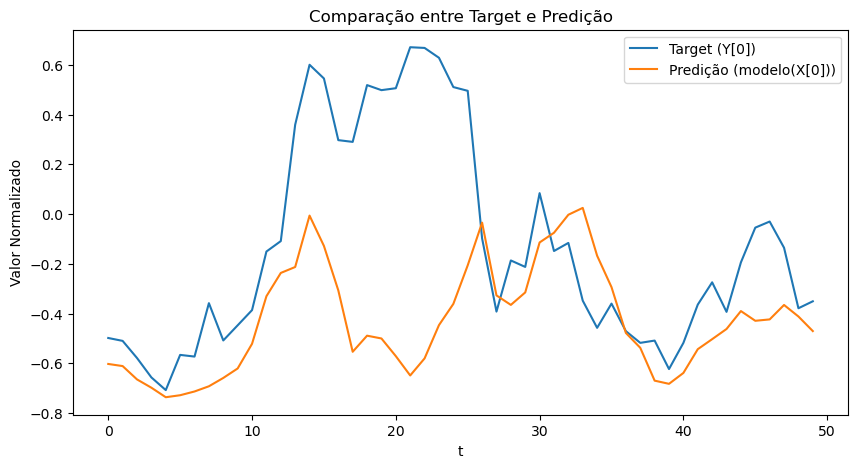

In [12]:
# Comparar Y[0] com Pred(X[0])

teste = torch.tensor(X[0]).to(device)

with torch.no_grad():
    saida = modelo(teste)
    pred = saida.squeeze().cpu().numpy()
    target = Y[0].cpu().numpy()
    
    print(f"Predito: {pred}")
    print(f"Original: {target}")
    
    
    
    t = range(len(target))
    plt.figure(figsize=(10,5))
    plt.plot(t, target, label='Target (Y[0])')
    plt.plot(t, pred, label='Predição (modelo(X[0]))')
    plt.xlabel('t')
    plt.ylabel('Valor Normalizado')
    plt.title('Comparação entre Target e Predição')
    plt.legend()
    plt.show()
  


## Testar usando metricas SKLEARN

In [13]:
# Comparar todas as janelas de X e Y

from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_list = []
mae_list = []

for i in range(len(X)//100):
  entrada = X[i].clone().detach().unsqueeze(0).to(device)
  with torch.no_grad():
    saida = modelo(entrada)
    pred = saida.squeeze().cpu().numpy()
    target = Y[i].cpu().numpy()
    
    mse_list.append(mean_squared_error(target, pred))
    mae_list.append(mean_absolute_error(target, pred))
    
print(f"MSE: {np.mean(mse_list)}")
print(f"MAE: {np.mean(mae_list)}")

MSE: 0.0867670048519253
MAE: 0.1581595329507013
